# Benchmark

---

## Setup

In [5]:
import os
dir = os.path.abspath('')  # directory of notebookimport numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae
import pandas as pd
import numpy as np

In [6]:
alpha = 0.00016  # watts / (units P1 * percent U1)
P1 = 200  # P1 units

# # Via inv_CpH, inv_CpS:
# Ua  = 0.05405229846011348
# Ub  = 0.05294170189601992
# CpH = 6.055477666513158
# CpS = 1.004922603766054

# Via CpH, CpS:
Ua  = 0.052384291033157684
Ub  = 0.060521133829919416
CpH = 5.568800661406845
CpS = 1.2773885658179458

In [7]:
tvec = [0, 50, 150, 450, 550, 1000]

def r(t):  # setpoint/reference
    return np.interp(t, tvec, [0, 0, 35, 35, 10, 10])

## Pyomo

In [8]:
m = pyo.ConcreteModel("TCLab Benchmark")
m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))

m.Th1 = pyo.Var(m.t)
m.Ts1 = pyo.Var(m.t)
m.u1 = pyo.Var(m.t, bounds=(0, 100))

m.dTh1 = dae.DerivativeVar(m.Th1)
m.dTs1 = dae.DerivativeVar(m.Ts1)

m.Th1[0].fix(0.0)  # initial conditions
m.Ts1[0].fix(0.0)
m.u1[0].fix(0.0)

@m.Constraint(m.t)  # first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh1[t]
        == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
    )

@m.Constraint(m.t)  # second differential equation
def sensor1(m, t):
    return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])

@m.Integral(m.t)  # integral of squared error
def ise(m, t):
    return (r(t) - m.Ts1[t]) ** 2

m.du1 = dae.DerivativeVar(m.u1)
@m.Integral(m.t)  # penalty term meant to smooth m.u1
def sum_du1(m, t):
    return m.du1[t] ** 2

@m.Objective(sense=pyo.minimize)  # objective function
def objective(m):
    return m.ise + 0.5 * m.sum_du1

pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
pyo.SolverFactory('ipopt').solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 3002, 'Number of variables': 3603, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.32678651809692383}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

## Results

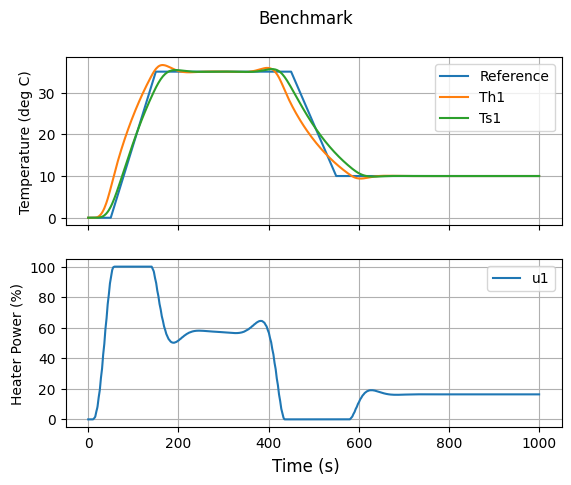

In [9]:
fig, ax = plt.subplots(2, sharex=True)
fig.suptitle("Benchmark")
fig.supxlabel("Time (s)")
ax[0].set_ylabel("Temperature (deg C)")
ax[1].set_ylabel("Heater Power (%)")

ax[0].plot(tvec, r(tvec), label="Reference")
ax[0].plot(m.t, m.Th1[:](), label="Th1")
ax[0].plot(m.t, m.Ts1[:](), label="Ts1")
ax[1].plot(m.t, m.u1[:](), label="u1")

for i in range(2):
    ax[i].legend()
    ax[i].grid()

## Save Results

In [53]:
solution = pd.DataFrame()

solution["Time"] = m.t
solution["Q1"] = m.u1[:]()

solution.to_csv(os.path.join(dir, "data", "solution_benchmark_0o5du1.csv"))